# Data Deep Dive

This notebook explains `src/cc_dqml/data.py`: how the synthetic clustered 8D binary dataset is generated, labeled, shuffled, split, and checked for feature-label correlation.

In [1]:
from pathlib import Path
import os
import sys

candidates = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
repo_root = next(path for path in candidates if (path / "src" / "cc_dqml").exists())
os.environ.setdefault("MPLCONFIGDIR", str(repo_root / ".cache" / "matplotlib"))
if str(repo_root / "src") not in sys.path:
    sys.path.insert(0, str(repo_root / "src"))

config_path = repo_root / "config" / "smoke.yaml"
if not config_path.exists():
    config_path = repo_root / "config-example" / "cc_dqml.yaml"

repo_root, config_path

(PosixPath('/Users/macos/Data/quantum/reproduce-distributed-quantum-ML-via-CC'),
 PosixPath('/Users/macos/Data/quantum/reproduce-distributed-quantum-ML-via-CC/config/smoke.yaml'))

## Imports

The public entry point is `generate_synthetic_dataset(settings, seed)`. The returned `DatasetSplit` dataclass contains train arrays, validation arrays, and the maximum absolute Pearson correlation between any feature and the label.

In [2]:
from dataclasses import asdict

import matplotlib.pyplot as plt
import numpy as np

from cc_dqml.config import load_config
from cc_dqml.data import DatasetSplit, generate_synthetic_dataset

config = load_config(config_path)
asdict(config.data)

{'n_features': 8,
 'n_samples': 64,
 'n_clusters': 8,
 'train_size': 48,
 'validation_size': 16,
 'sphere_radius': 0.7853981633974483}

## Generate a split

The generator samples unique hypercube divisions as cluster centers, assigns balanced `-1` and `+1` labels, samples points inside small balls around each center, shuffles everything, then slices train and validation arrays.

In [3]:
dataset = generate_synthetic_dataset(config.data, config.experiment.dataset_seed)
isinstance(dataset, DatasetSplit), dataset

(True,
 DatasetSplit(x_train=array([[-0.98833684, -0.92676972, -1.08292743, -0.54214743, -0.46412588,
         -1.03909914, -1.02406152,  0.42821356],
        [ 1.06462119,  0.78246023, -0.56542463, -0.48932465,  1.02824357,
         -1.28480728, -0.52597448, -0.71369096],
        [-0.73525843, -0.88154156, -0.14299697, -0.86706214, -1.09275906,
         -0.73458089, -0.79517227,  1.0537737 ],
        [ 0.89665215,  0.27528673, -0.8910845 , -0.86584689,  1.05866138,
         -0.67694125,  0.96495087,  0.45505006],
        [ 0.90838612,  0.89877871, -0.53284066, -0.93261538,  1.11492877,
         -0.84146508, -0.4782444 , -0.86983103],
        [ 0.74878986, -0.65086137,  0.66447266,  0.80712755, -0.87907101,
         -0.69083799,  0.29987471, -0.57823476],
        [-0.93353924, -1.0414495 , -0.5023194 , -0.69550468, -0.8599439 ,
         -0.82931369, -0.8907842 ,  0.20107259],
        [-1.12990933, -0.58285157,  0.7192188 , -0.92971858, -0.61366729,
         -0.94283711, -0.32654555, -0

In [4]:
summary = {
    "x_train": dataset.x_train.shape,
    "y_train": dataset.y_train.shape,
    "x_val": dataset.x_val.shape,
    "y_val": dataset.y_val.shape,
    "max_abs_pearson": dataset.max_abs_pearson,
}
summary

{'x_train': (48, 8),
 'y_train': (48,),
 'x_val': (16, 8),
 'y_val': (16,),
 'max_abs_pearson': 0.6971840437679065}

## Label balance and feature ranges

The labels are binary and balanced by cluster before shuffling. Feature values are continuous because each sample is drawn from a ball around a signed cluster center.

In [5]:
all_x = np.vstack([dataset.x_train, dataset.x_val])
all_y = np.concatenate([dataset.y_train, dataset.y_val])

labels, counts = np.unique(all_y, return_counts=True)
feature_ranges = np.column_stack([all_x.min(axis=0), all_x.max(axis=0)])

{
    "label_counts": dict(zip(labels.astype(int), counts, strict=True)),
    "feature_min_max": np.round(feature_ranges, 3),
}

{'label_counts': {np.int64(-1): np.int64(32), np.int64(1): np.int64(32)},
 'feature_min_max': array([[-1.193,  1.255],
        [-1.351,  1.343],
        [-1.205,  1.236],
        [-1.185,  1.255],
        [-1.168,  1.228],
        [-1.338, -0.393],
        [-1.24 ,  1.281],
        [-1.249,  1.205]])}

## Correlation check

The paper-style data is designed so single features should not trivially reveal the label. `max_abs_pearson` records the strongest absolute feature-label Pearson correlation in the generated dataset.

In [6]:
correlations = np.array([
    np.corrcoef(all_x[:, feature], all_y)[0, 1]
    for feature in range(config.data.n_features)
])

for feature, correlation in enumerate(correlations):
    print(f"feature_{feature}: pearson={correlation:+.4f}")

print("max_abs_pearson:", float(np.nanmax(np.abs(correlations))))

feature_0: pearson=-0.2148
feature_1: pearson=+0.2410
feature_2: pearson=+0.2238
feature_3: pearson=+0.2518
feature_4: pearson=+0.2833
feature_5: pearson=-0.2637
feature_6: pearson=-0.6972
feature_7: pearson=-0.1791
max_abs_pearson: 0.6971840437679065


## Quick projection

This 2D view is only a projection of the 8D dataset, but it helps show the clustered structure and mixed labels.

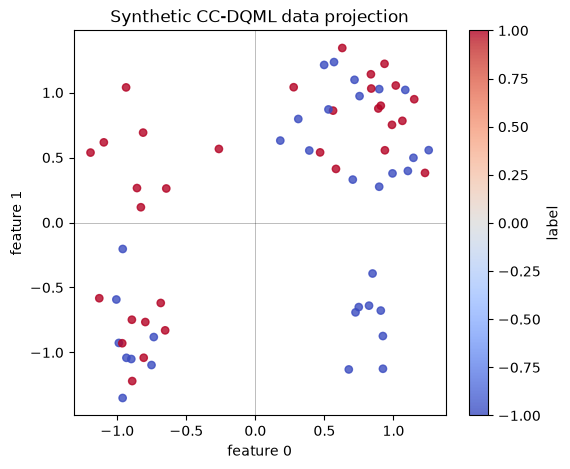

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))
scatter = ax.scatter(all_x[:, 0], all_x[:, 1], c=all_y, cmap="coolwarm", s=28, alpha=0.8)
ax.set_xlabel("feature 0")
ax.set_ylabel("feature 1")
ax.set_title("Synthetic CC-DQML data projection")
ax.axhline(0, color="black", linewidth=0.6, alpha=0.3)
ax.axvline(0, color="black", linewidth=0.6, alpha=0.3)
fig.colorbar(scatter, ax=ax, label="label")
plt.show()

## Sanity checks

These checks encode the assumptions that `train.py` and `circuits.py` rely on: 8 input features, configured split sizes, and labels in `{-1, +1}`.

In [8]:
assert dataset.x_train.shape == (config.data.train_size, 8)
assert dataset.x_val.shape == (config.data.validation_size, 8)
assert dataset.y_train.shape == (config.data.train_size,)
assert dataset.y_val.shape == (config.data.validation_size,)
assert set(np.unique(all_y)) == {-1.0, 1.0}
assert np.isclose(dataset.max_abs_pearson, float(np.nanmax(np.abs(correlations))))

"data sanity checks passed"

'data sanity checks passed'